### Assignment No. 2

### Name : Jawale Kishor Macchindra
### Roll no. : EN23107052
### Batch : C

In [1]:
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
df = pd.read_csv("iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
print(df.shape)
print(df.info())
print(df.describe())

(150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.5

In [5]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [6]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [8]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model = keras.Sequential([

    layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),

    layers.Dense(8, activation='relu'),

    layers.Dense(3, activation='softmax')

])

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 265ms/step - accuracy: 0.2812 - loss: 1.0974 - val_accuracy: 0.2500 - val_loss: 1.0957
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.3229 - loss: 1.0744 - val_accuracy: 0.2917 - val_loss: 1.0734
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.3333 - loss: 1.0503 - val_accuracy: 0.3750 - val_loss: 1.0516
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.3542 - loss: 1.0274 - val_accuracy: 0.4583 - val_loss: 1.0297
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.3854 - loss: 1.0057 - val_accuracy: 0.5000 - val_loss: 1.0080
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5104 - loss: 0.9818 - val_accuracy: 0.5000 - val_loss: 0.9882
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5729 - loss: 0.9607 - val_accuracy: 0.7083 - val_loss: 0.9690
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.6354 - loss: 0.9403 - val_accuracy: 0.7917 - val_loss: 0.950

In [16]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9333 - loss: 0.3278
Test Accuracy: 0.9333333373069763


In [17]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
[[10  0  0]
 [ 0  7  2]
 [ 0  0 11]]


In [18]:
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.78      0.88         9
           2       0.85      1.00      0.92        11

    accuracy                           0.93        30
   macro avg       0.95      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



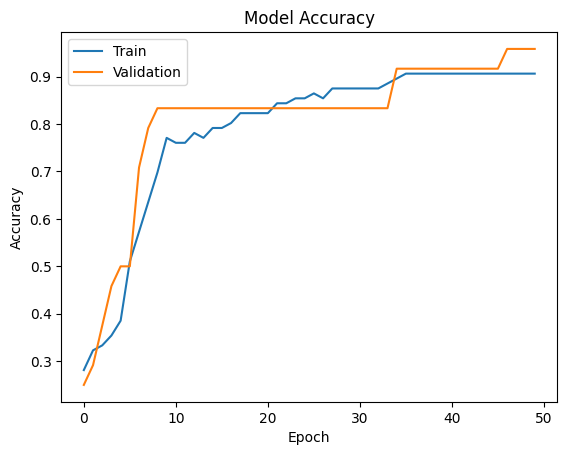

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

In [20]:
model.save("iris_ai_model.keras")